In [1]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
download_path = kagglehub.competition_download("dogs-vs-cats")

100%|██████████| 812M/812M [00:06<00:00, 123MB/s]

Extracting files...


In [3]:
import zipfile

with zipfile.ZipFile(download_path + "/train.zip", "r") as zip_ref:
    zip_ref.extractall(".")

In [4]:

import os, shutil, pathlib

# Path to the directory where the original dataset was uncompressed
original_dir = pathlib.Path("train")
# Directory where we will store our smaller dataset
new_base_dir = pathlib.Path("dogs_vs_cats_small")

# Utility function to copy cat (respectively, dog) images from index
# `start_index` to index `end_index` to the subdirectory
# `new_base_dir/{subset_name}/cat` (respectively, dog). "subset_name"
# will be either "train," "validation," or "test."
def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)

# Creates the training subset with the first 1,000 images of each
# category
make_subset("train", start_index=0, end_index=1000)
# Creates the validation subset with the next 500 images of each
# category
make_subset("validation", start_index=1000, end_index=1500)
# Creates the test subset with the next 1,000 images of each category
make_subset("test", start_index=1500, end_index=2500)

In [5]:
import keras
from keras import layers

# The model expects RGB images of size 180 x 180.
inputs = keras.Input(shape=(180, 180, 3))
# Rescales inputs to the [0, 1] range by dividing them by 255
x = layers.Rescaling(1.0 / 255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)
# Flattens the 3D activations with shape (height, width, 512) into 1D
# activations with shape (512,) by averaging them over spatial
# dimensions
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569,089 (5.99 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

### Data preprocessing

In [8]:
from keras.utils import image_dataset_from_directory

batch_size = 64
image_size = (180, 180)
train_dataset = image_dataset_from_directory(
    new_base_dir / "train", image_size=image_size, batch_size=batch_size
)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation", image_size=image_size, batch_size=batch_size
)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test", image_size=image_size, batch_size=batch_size
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [20]:
import numpy as np
import tensorflow as tf

random_numbers = np.random.normal(size=(1000, 16))
dataset = tf.data.Dataset.from_tensor_slices(random_numbers)

In [21]:
for i, element in enumerate(dataset):
    print(element.shape)
    if i >= 2:
        break

(16,)
(16,)
(16,)


In [22]:
batched_dataset = dataset.batch(32)
for i, element in enumerate(batched_dataset):
    print(element.shape)
    if i >= 2:
        break

(32, 16)
(32, 16)
(32, 16)


In [23]:
reshaped_dataset = dataset.map(
    lambda x: tf.reshape(x, (4, 4)),
    num_parallel_calls=8)
for i, element in enumerate(reshaped_dataset):
    print(element.shape)
    if i >= 2:
        break

(4, 4)
(4, 4)
(4, 4)


In [16]:
for i, element in enumerate(reshaped_dataset):
    print(element.shape)
    if i >= 2:
        break

(4, 4)
(4, 4)
(4, 4)


In [24]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (64, 180, 180, 3)
labels batch shape: (64,)


In [25]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 379ms/step - accuracy: 0.5125 - loss: 0.6957 - val_accuracy: 0.5000 - val_loss: 0.6923
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.5155 - loss: 0.6939 - val_accuracy: 0.5290 - val_loss: 0.6913
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.5410 - loss: 0.6874 - val_accuracy: 0.5510 - val_loss: 0.6833
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.5790 - loss: 0.6755 - val_accuracy: 0.6090 - val_loss: 0.6577
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.5950 - loss: 0.6598 - val_accuracy: 0.5980 - val_loss: 0.6580
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.6115 - loss: 0.6639 - val_accuracy: 0.5980 - val_loss: 0.6551
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.6185 - loss: 0.6430 - val_accuracy: 0.6670 - val_loss: 0.6255
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.6650 - loss: 0.6093 - val_accuracy: 0

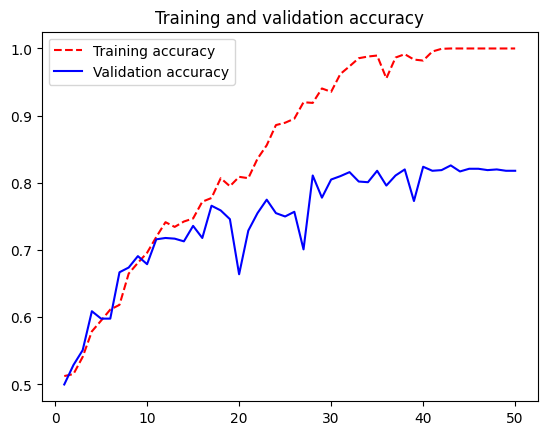

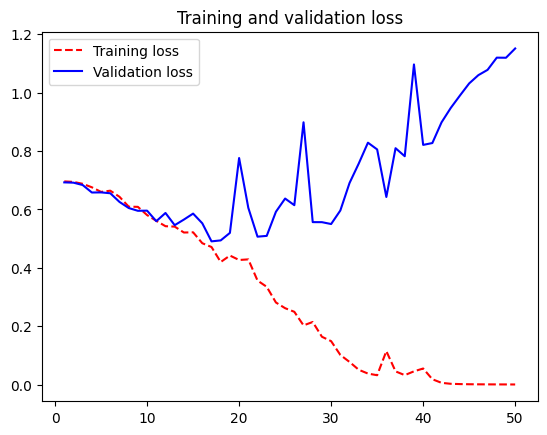

In [26]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [27]:
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.7645 - loss: 0.4935
Test accuracy: 0.765


### Data augmentation

In [28]:
# Defines the transformations to apply as a list
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]

# Creates a function that applies them sequentially
def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, targets

# Maps this function into the dataset
augmented_train_dataset = train_dataset.map(
    data_augmentation, num_parallel_calls=8
)
# Enables prefetching of batches on GPU memory; important for best
# performance
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

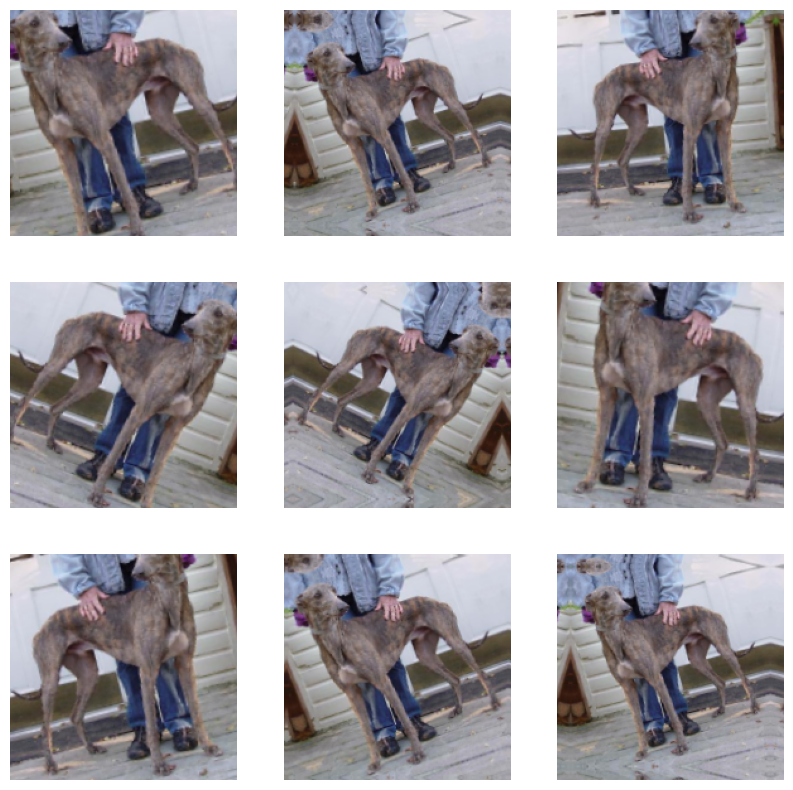

In [29]:
plt.figure(figsize=(10, 10))
# You can use take(N) to only sample N batches from the dataset. This
# is equivalent to inserting a break in the loop after the Nth batch.
for image_batch, _ in train_dataset.take(1):
    image = image_batch[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image, _ = data_augmentation(image, None)
        augmented_image = keras.ops.convert_to_numpy(augmented_image)
        # Displays the first image in the output batch. For each of the
        # nine iterations, this is a different augmentation of the same
        # image.
        plt.imshow(augmented_image.astype("uint8"))
        plt.axis("off")

In [30]:
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1.0 / 255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [31]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    # Since we expect the model to overfit slower, we train for more
    # epochs.
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 434ms/step - accuracy: 0.4970 - loss: 0.6948 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 438ms/step - accuracy: 0.4950 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 438ms/step - accuracy: 0.5300 - loss: 0.6912 - val_accuracy: 0.5040 - val_loss: 0.6910
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 684ms/step - accuracy: 0.5350 - loss: 0.6924 - val_accuracy: 0.5230 - val_loss: 0.6912
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 440ms/step - accuracy: 0.4960 - loss: 0.6914 - val_accuracy: 0.5590 - val_loss: 0.6875
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 466ms/step - accuracy: 0.5240 - loss: 0.6886 - val_accuracy: 0.5700 - val_loss: 0.6817
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 419ms/step - accuracy: 0.5550 - loss: 0.6816 - val_accuracy: 0.5500 - val_loss: 0.6831
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 419ms/step - accuracy: 0.5820 - loss: 0.6680 - 

In [32]:
test_model = keras.models.load_model(
    "convnet_from_scratch_with_augmentation.keras"
)
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.8410 - loss: 0.4123
Test accuracy: 0.841


### Using a pretrained model

In [33]:
import keras_hub

conv_base = keras_hub.models.Backbone.from_preset("xception_41_imagenet")

100%|██████████| 1.79k/1.79k [00:00<00:00, 8.34MB/s]


100%|██████████| 79.9M/79.9M [00:02<00:00, 35.5MB/s]


In [34]:
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(180, 180),
)

In [35]:
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = preprocessor(images)
        features = conv_base.predict(preprocessed_images, verbose=0)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

In [36]:
train_features.shape

(2000, 6, 6, 2048)

In [37]:
inputs = keras.Input(shape=(6, 6, 2048))
# Averages spatial dimensions to flatten the feature map
x = layers.GlobalAveragePooling2D()(inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    train_features,
    train_labels,
    epochs=10,
    validation_data=(val_features, val_labels),
    callbacks=callbacks,
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9660 - loss: 0.0978 - val_accuracy: 0.9650 - val_loss: 0.0995
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9900 - loss: 0.0264 - val_accuracy: 0.9860 - val_loss: 0.0461
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9975 - loss: 0.0109 - val_accuracy: 0.9800 - val_loss: 0.0545
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9965 - loss: 0.0084 - val_accuracy: 0.9870 - val_loss: 0.0494
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9960 - loss: 0.0100 - val_accuracy: 0.9880 - val_loss: 0.0511
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9985 - loss: 0.0042 - val_accuracy: 0.9860 - val_loss: 0.0563
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9870 - val_loss: 0.0574
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 8.9853e-04 - val_accuracy: 0.9880

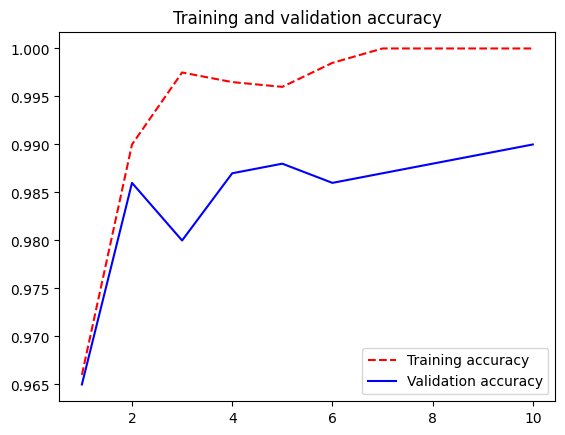

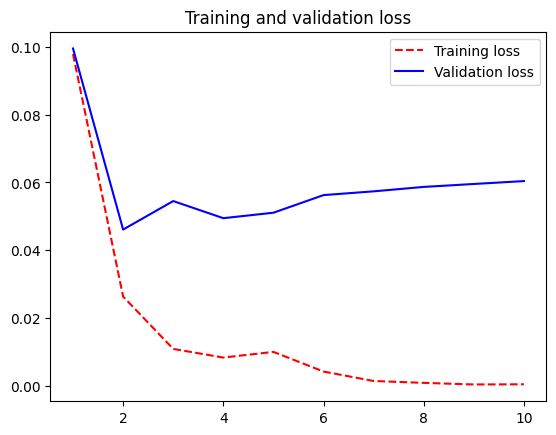

In [38]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [39]:
test_model = keras.models.load_model("feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9835 - loss: 0.0539
Test accuracy: 0.984


### Feature extraction together with data augmentation

In [40]:
import keras_hub

conv_base = keras_hub.models.Backbone.from_preset(
    "xception_41_imagenet",
    trainable=False,
)

In [41]:
inputs = keras.Input(shape=(180, 180, 3))
x = preprocessor(inputs)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [42]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.8835 - loss: 0.2431 - val_accuracy: 0.9500 - val_loss: 0.6824
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 836ms/step - accuracy: 0.9460 - loss: 0.1638 - val_accuracy: 0.9590 - val_loss: 0.6403
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 749ms/step - accuracy: 0.9600 - loss: 0.1143 - val_accuracy: 0.8830 - val_loss: 2.5924
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 806ms/step - accuracy: 0.9665 - loss: 0.1084 - val_accuracy: 0.9200 - val_loss: 0.5515
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 822ms/step - accuracy: 0.9580 - loss: 0.1167 - val_accuracy: 0.9180 - val_loss: 0.6899
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 760ms/step - accuracy: 0.9715 - loss: 0.0775 - val_accuracy: 0.9150 - val_loss: 0.3310
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 758ms/step - accuracy: 0.9745 - loss: 0.0723 - val_accuracy: 0.8970 - val_loss: 0.5457
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 784ms/step - accuracy: 0.9795 - loss: 0.0670 - val_accura

In [43]:
test_model = keras.models.load_model(
    "feature_extraction_with_data_augmentation.keras"
)
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 273ms/step - accuracy: 0.9620 - loss: 0.1076
Test accuracy: 0.962


### Fine Tuning

In [49]:
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9910 - loss: 0.0307 - val_accuracy: 0.9620 - val_loss: 0.1108
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 883ms/step - accuracy: 0.9890 - loss: 0.0321 - val_accuracy: 0.9620 - val_loss: 0.1001
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 941ms/step - accuracy: 0.9905 - loss: 0.0269 - val_accuracy: 0.9640 - val_loss: 0.0963
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 895ms/step - accuracy: 0.9950 - loss: 0.0171 - val_accuracy: 0.9660 - val_loss: 0.0945
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 738ms/step - accuracy: 0.9955 - loss: 0.0165 - val_accuracy: 0.9650 - val_loss: 0.0954
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 759ms/step - accuracy: 0.9965 - loss: 0.0139 - val_accuracy: 0.9660 - val_loss: 0.0964
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 696ms/step - accuracy: 0.9945 - loss: 0.0151 - val_accuracy: 0.9660 - val_loss: 0.0976
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 722ms/step - accuracy: 0.9920 - loss: 0.0204 - val_accura

In [50]:
model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 279ms/step - accuracy: 0.9645 - loss: 0.1223
Test accuracy: 0.965
